

**Principal component analysis**

**Introduction:**

Hyperspectral images are scientific images of the Earth, acquired by satellites or aicrafts; rather than having three R/G/B color channels, these images have a lot more “color” components obtained through a fine sampling of the wavelength (hence the name “hyper”-spectral). The
resulting 3-dimensional dataset has one image (spectral band or “color”) for every sampled wavelength, which represents the measured radiance from each pixel at that specific wavelength. Hyperspectral images are very useful for image analysis. For every pixel at a given spatial position, it is possible to extract a so-called spectral vector, i.e. the 1-dimensional vector of values assumed by that pixel at all wavelengths. Assuming that each pixel is composed of just one substance, the spectral vector represents the radiance of that substance at all the wavelengths that have been
sampled. Spectral vectors, therefore, can be used to infer which substance is contained in a given pixel – a typical classification problem that has a lot of practical applications in agriculture, analysis of land use / land cover, and other applications related to the study of the environment.


we will use a real hyperspectral image that has been acquired by the AVIRIS instrument, an airborne hyperspectral imager operated by the NASA. The image represents a scene of Indian Pines (Indiana, USA). It has a size of 145x145 pixels and 220 spectral bands. Along with the image, a ground truth is available, in terms of labels specifying which class (out of 16) each pixel belongs to. The classes are reported below; for more information, see
http://www.ehu.eus/ccwintco/index.php/Hyperspectral_Remote_Sensing_Scenes#Indian_Pines

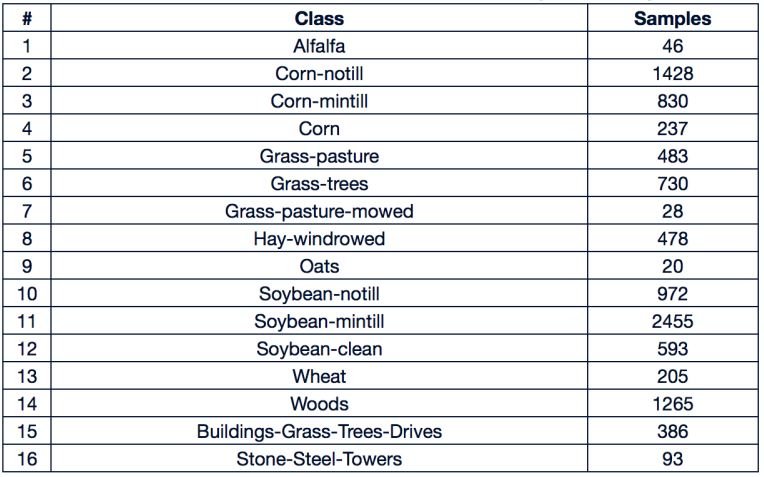

The purpose of this computer lab is twofold:
To apply PCA to the spectral vectors in order to reduce their dimensionality.

*   To apply PCA to the spectral vectors in order to reduce their dimensionality.
*   To perform classification on the reduced data (optional)

**PCA**


In this step, you will employ the Indian Pines dataset. You will not do this for the entire dataset, but only for the spectral vectors belonging to **two classes** (as in the optional step we will perform 2-class classification on the PCA coefficients).

**Reminder:** the input to the PCA must always have zero mean: besides the sample covariance, you will have to compute the **mean value μ** over the training set and subtract it from each test vector before applying PCA.

**Task:** **we** have to reduce the dimensionality of the spectral vectors of the two classes you have chosen using PCA. In particular, you should perform the following:


*   Extract spectral vectors of two classes, as described above (see sample code below).
*   Estimate the sample covariance matrix of the dataset as a whole (i.e., considering together spectral vectors of the two classes)
*   Perform the eigenvector decomposition of the sample covariance matrix. You can use the numpy linalg.eig function, which outputs the matrix containing the eigenvectors as columns, and a diagonal matric containing the eigenvalues on the main diagonal.
  * Note: in the output matrix, eigenvectors/eigenvalues are not necessarily ordered by eigenvalue magnitude. You should sort them by yourself.
*   Choose a number of dimensions K<=220.
*   Construct the eigenvector matrix W for K components (i.e., select the last K columns)
*   Using W, compute the PCA coefficients for each spectral vector in the data set
*   Then from the PCA coefficients obtain an approximation of the corresponding vector and compute the error (mean square error - MSE)
*   Plot the average MSE over the test set as a function of K.
*   Plot the eigenvectors corresponding to the 3 largest eigenvalues – this will give you an idea of the basis functions employed by PCA

In [ ]:
import numpy as np
import h5py
import scipy.io
import matplotlib.pyplot as plt

# Load the dataset
# Indian_pines contains spectral data
mat = scipy.io.loadmat('Indian_pines.mat')
indian_pines = np.array(mat['indian_pines'])

# Ground truth labels
mat_gt = scipy.io.loadmat('Indian_pines_gt.mat')
indian_pines_gt = np.array(mat_gt['indian_pines_gt'])

**Extract spectral vectors of two classes, as described above (see sample code below).**

In [ ]:
# Define two classes to extract
class1_value = 1  # Example class value for class 1
class2_value = 2  # Example class value for class 2

# Extract spectral vectors for class 1
class1 = np.zeros((1500, 220))
n1 = 0
for i in range(indian_pines_gt.shape[0]):
    for j in range(indian_pines_gt.shape[1]):
        if indian_pines_gt[i, j] == class1_value:
            class1[n1, :] = indian_pines[i, j, :] / 1.0
            n1 += 1
class1 = class1[:n1, :]

# Extract spectral vectors for class 2
class2 = np.zeros((1500, 220))
n2 = 0
for i in range(indian_pines_gt.shape[0]):
    for j in range(indian_pines_gt.shape[1]):
        if indian_pines_gt[i, j] == class2_value:
            class2[n2, :] = indian_pines[i, j, :] / 1.0
            n2 += 1
class2 = class2[:n2, :]

# Combine spectral vectors of both classes into one dataset
data = np.vstack((class1, class2))


**Estimate the sample covariance matrix of the dataset as a whole (i.e., considering together spectral vectors of the two classes)**

In [ ]:
# Compute the mean vector of the dataset
mean_vector = np.mean(data, axis=0)

# Center the data (subtract the mean vector from each sample)
data_centered = data - mean_vector

# Compute the covariance matrix
cov_matrix = np.cov(data_centered, rowvar=False)


**Perform the eigenvector decomposition of the sample covariance matrix. You can use the numpy linalg.eig function, which outputs the matrix containing the eigenvectors as columns, and a diagonal matric containing the eigenvalues on the main diagonal.**

In [ ]:
from numpy import linalg as LA

w, v = LA.eig(cov_matrix)

# Sort eigenvalues and eigenvectors by descending eigenvalue magnitude
sorted_indices = np.argsort(w)[::-1]  # Indices of sorted eigenvalues
w = w[sorted_indices]  # Sorted eigenvalues
v = v[:, sorted_indices]  # Corresponding sorted eigenvectors

**Choose a number of dimensions K<=220.Construct the eigenvector  matrix W for K components (i.e., select the last K columns)**

In [ ]:
# Choose the number of components K (K <= 220)
K = 10  # Example: reduce to 10 dimensions

# Construct the eigenvector matrix W with K components
W = v[:, :K]  # Use sorted eigenvectors from Part 4

**Using W, compute the PCA coefficients for each spectral vector in the data set. Then from the PCA coefficients obtain an approximation of the corresponding vector and compute the error (mean square error - MSE)**

In [ ]:
# Compute PCA coefficients (project data onto PCA basis)
pca_coefficients = np.dot(data_centered, W)

# Reconstruct the data from PCA coefficients
reconstructed_data = np.dot(pca_coefficients, W.T) + mean_vector

# Compute the Mean Square Error (MSE) for each vector
mse = np.mean((data - reconstructed_data) ** 2, axis=1)

**Plot the average MSE over the test set as a function of K.**

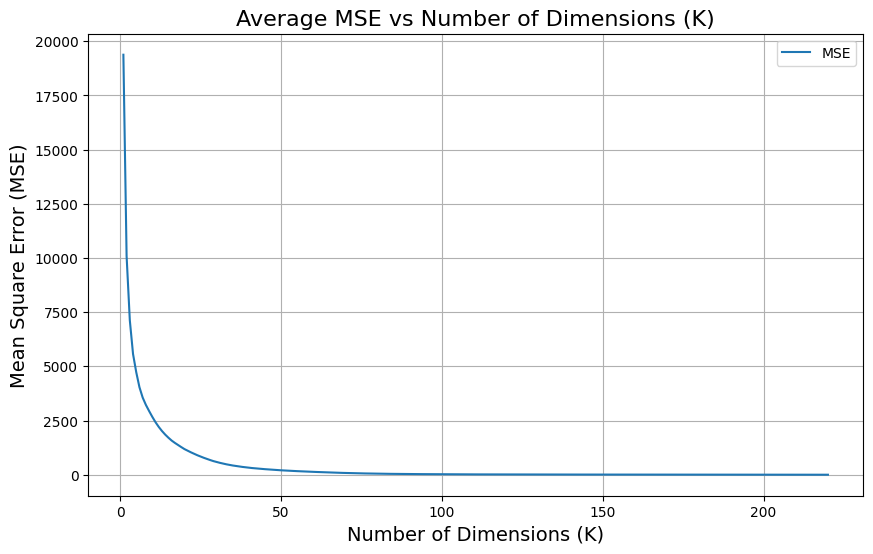

In [ ]:
# Calculate average MSE for different values of K
mse_averages = []
for k in range(1, 221):  # Test K from 1 to 220
    W_k = v[:, :k]  # Use sorted eigenvectors
    pca_coefficients_k = np.dot(data_centered, W_k)
    reconstructed_data_k = np.dot(pca_coefficients_k, W_k.T) + mean_vector
    mse_k = np.mean((data - reconstructed_data_k) ** 2)
    mse_averages.append(mse_k)

# Plot the average MSE against the number of dimensions (K)
plt.figure(figsize=(10, 6))
plt.plot(range(1, 221), mse_averages, label="MSE")
plt.xlabel("Number of Dimensions (K)", fontsize=14)
plt.ylabel("Mean Square Error (MSE)", fontsize=14)
plt.title("Average MSE vs Number of Dimensions (K)", fontsize=16)
plt.grid()
plt.legend()
plt.show()


**Plot the eigenvectors corresponding to the 3 largest eigenvalues – this will give you an idea of the basis functions employed by PCA**

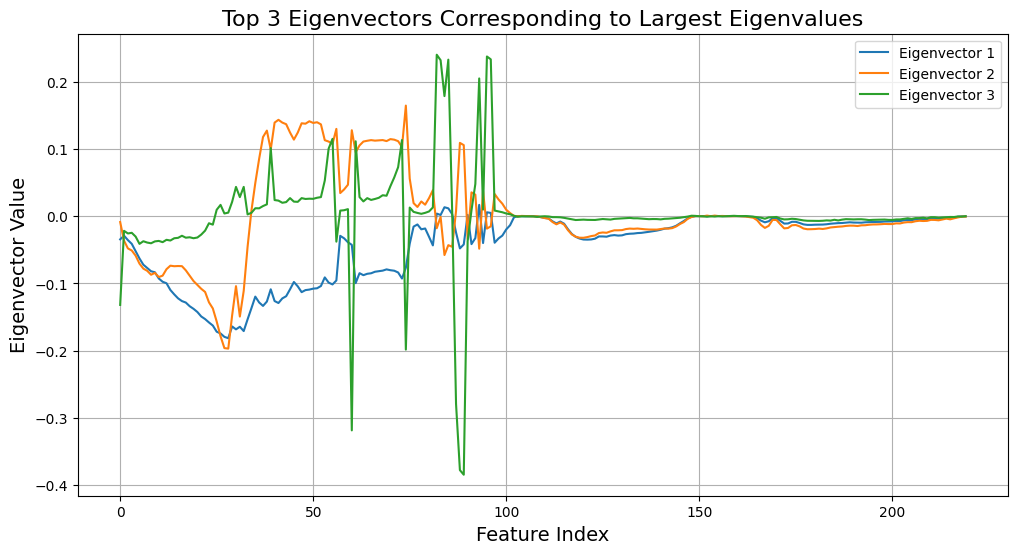

In [ ]:
# Plot the eigenvectors corresponding to the top 3 eigenvalues
plt.figure(figsize=(12, 6))
for i in range(3):
    plt.plot(v[:, i], label=f"Eigenvector {i+1}")  # Use sorted eigenvectors
plt.xlabel("Feature Index", fontsize=14)
plt.ylabel("Eigenvector Value", fontsize=14)
plt.title("Top 3 Eigenvectors Corresponding to Largest Eigenvalues", fontsize=16)
plt.legend()
plt.grid()
plt.show()


**Comments**

The results of PCA on the spectral data can be summarized as follows:

1. **Top 3 Eigenvectors:**  
   The plotted eigenvectors corresponding to the three largest eigenvalues reveal the dominant basis functions selected by PCA. These eigenvectors represent the directions of maximum variance in the dataset. The smooth patterns in these eigenvectors indicate how the data is distributed across the 220 features and how PCA identifies meaningful components for dimensionality reduction.

2. **MSE vs. Number of Dimensions (K):**  
   The second plot shows the relationship between the number of retained dimensions (\(K\)) and the Mean Square Error (MSE). As expected, increasing \(K\) reduces the MSE, indicating better reconstruction accuracy. The steep drop in MSE for smaller values of \(K\) shows that most of the data’s variance is captured in the first few principal components. After around \(K = 50\), the MSE flattens, suggesting diminishing returns from adding more dimensions.

3. **Dimensionality Reduction:**  
   PCA effectively reduces the dimensionality of the dataset while retaining most of the variance. This makes PCA a suitable preprocessing step for further classification or clustering tasks.

In summary, the PCA results demonstrate its ability to simplify high-dimensional data while preserving meaningful information, as indicated by the rapid decrease in MSE and the visualization of the top eigenvectors.